# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
3. True or false, and explain: Logistic regression is a linear model.
4. True or false, and explain: Logistic regression cannot be used for classification.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

1. Linear models return a numeric value between - ∞ and + ∞, because it assumes all relationship are linear. However, in the real-world relationship is not linear so that linear model cannot produce a interpretable results for classification problem or probability problem. Therefore, we need general linear models that assume a linear relationship in a latent space and apply a link (activation) function to map it to the correct output domain. This allows us to model nonlinear behavior while still keeping the simplicity and interpretability of linear models.

2. Binary and categorical cross entropy are effective for logistic regression because they correspond to the negative log-likelihood of the underlying Bernoulli and categorical distributes

3. True, logistic regression is a linear model in the sense that it models a linear relationship between the features and the log-odds of the outcome.

4. True, logistic can convert its linear score into a probability through applying a sigmoid function, which allows it to be used for classification.

5. In logistic regression, a coefficient represents the change in the log-odds of the outcome for a one-unit increase in the feature, is not a direct change in the predicted probability.

6. False, logistic regression is nonlinear in its output but linear in the features, so feature engineering (interactions and transformations) is still necessary to capture complex relationships.

7. False, logistic regression is designed for classification problems, while linear regression is for continuous outcomes that neither is universally better and should be chosen based on the problem type.

In [549]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


In [550]:
DATA = pd.read_csv("data/data.csv", sep=";")
DATA.info()
DATA.describe()
DATA.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                   

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [551]:
# 2.1
DATA["Binary_Target"] =  DATA["Target"].map({
    "Dropout": 1,
    "Graduate": 0, 
    "Enrolled": 0
})

DATA.head()
DATA["Binary_Target"].value_counts()

Binary_Target
0    3003
1    1421
Name: count, dtype: int64

In [552]:
# 2.2

#set X
X = DATA[[ 
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment"
    ]]

# standardize age
scaler = StandardScaler()
X["Tuition fees up to date"] = scaler.fit_transform(X[["Tuition fees up to date"]])

# set y
y = DATA["Binary_Target"]

# model and fitting
reg = LogisticRegression(penalty=None, max_iter=5000)
reg = reg.fit(X,y)

display(pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]}))


/var/folders/t6/fdg24_1x5970273s9fgndyg40000gn/T/ipykernel_38150/2540105752.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Tuition fees up to date"] = scaler.fit_transform(X[["Tuition fees up to date"]])
/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Variable,Coefficient
0,Debtor,0.527252
1,Tuition fees up to date,-0.844744
2,Scholarship holder,-1.242247
3,Age at enrollment,0.049843


Student debt and age at enrollment increase the dropout probability. Tuition fees up to data and scholarship holder decreases the drop out probability. Tuition fee up to date significantly decrease the dropout risk.

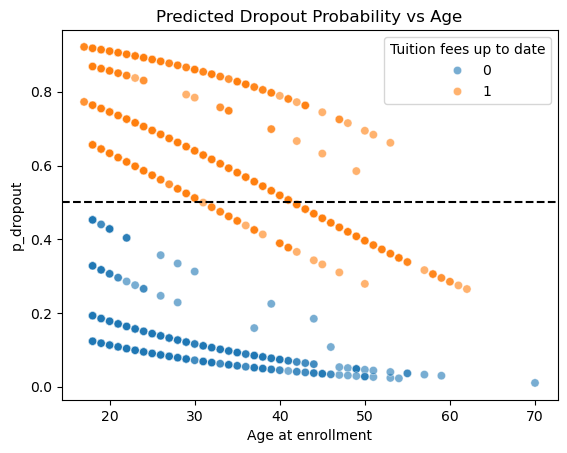

Average reduction in predicted dropout probability due to tuition fees up to date: 0.6181074498113096 %.


In [553]:
# 2.3

# Regression
DATA["p_dropout"] = reg.predict_proba(X)[:, 0]

sns.scatterplot(
    x="Age at enrollment",
    y="p_dropout",
    hue="Tuition fees up to date",
    data=DATA,
    alpha=0.6
)

plt.title("Predicted Dropout Probability vs Age")
plt.axhline(0.5, linestyle="--", color="black")  
plt.show()

avg_p = DATA.groupby("Tuition fees up to date")["p_dropout"].mean()

reduction = avg_p[0] - avg_p[1]
print("Average reduction in predicted dropout probability due to tuition fees up to date:", -reduction, "%.")


The younger for the student to enroll, the more reduction in predicted dropout probability that a student could have when their tuition fees are up to date.

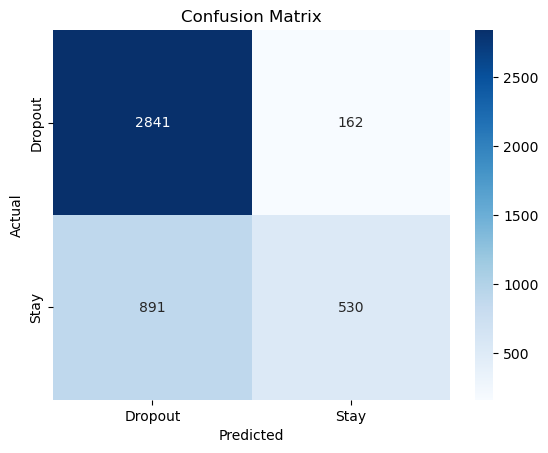

Accuracy: 0.7619801084990958


In [554]:
# 2.4
y_pred = reg.predict(X)

# confusion matrix
cm = confusion_matrix(y, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Dropout", "Stay"],
    yticklabels=["Dropout", "Stay"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# accuracy
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

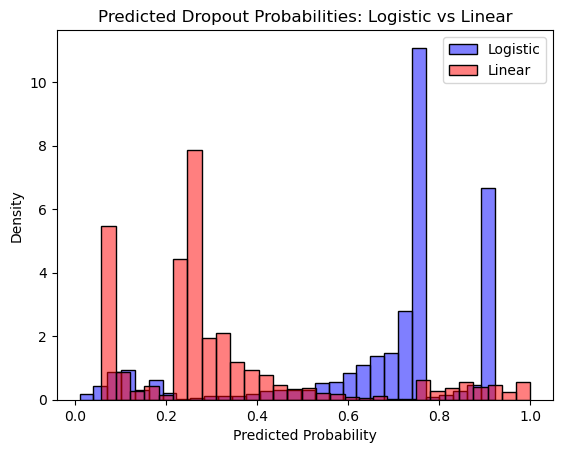

In [555]:
# 2.5

# set model
linear = LinearRegression()
linear.fit(X, y)

DATA["p_dropout_linear"] = linear.predict(X).clip(0, 1)

sns.histplot(
    DATA["p_dropout"], 
    color="blue",
    label="Logistic", 
    stat="density"
    , bins=30,
    alpha=0.5
    )

sns.histplot(
    DATA["p_dropout_linear"], 
    color="red",
    label="Linear", 
    stat="density",
    bins=30,
    alpha=0.5
    )

plt.legend()
plt.title("Predicted Dropout Probabilities: Logistic vs Linear")
plt.xlabel("Predicted Probability")
plt.show()

The histograms show that logistic regression predicted that most the students' probability to dropout is low, but the linear regression model predicted high dropout probability (>60%) for more than half of the students. In order to better compare both regression in the same chart, I clipped the output of the linear regression because it is not constrained between 0 and 1. This indicates that the linear model is poorly calibrated for probability estimation. Overall, logistic regression provides more reliable and interpretable probability predictions, while the linear model exhibits structural limitations when applied to a binary classification problem.

### 2.6
The students most at risk of dropping out are those experiencing financial strain, particularly those who are in debt, not up to date on tuition payments, and not receiving scholarships. Older students also show slightly higher risk, likely due to additional external responsibilities.

Interventions should therefore focus on reducing financial pressure and increasing flexibility for the students. These could include offering emergency financial aid, flexible payment plans, and targeted scholarships for at-risk students. Additionally, implementing early warning systems based on tuition payment status could allow institutions to intervene before students disengage. For older students, flexible scheduling and part-time options may further improve retention.

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,Debtor,Tuition fees up to date,Curricular units 1st sem (approved)
Dropout,0.364253,-1.782824,-0.289422
Enrolled,0.279227,0.207343,-0.025537
Graduate,-0.643480,1.575481,0.314959


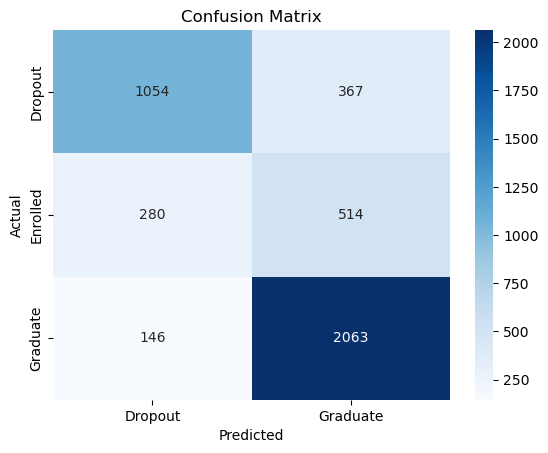

Accuracy: 0.7045660036166366


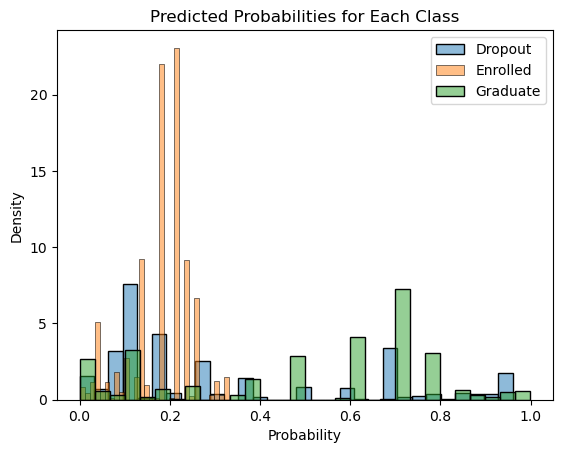

In [556]:
# 2.7

# set X and y
X = DATA[[
    "Debtor",
    "Tuition fees up to date",
    "Curricular units 1st sem (approved)"
]]


y = DATA["Target"]

# build model
multi_reg = LogisticRegression(penalty=None, max_iter=1000)
multi_reg.fit(X, y)

# model coefficient
coef = pd.DataFrame(
    multi_reg.coef_,
    columns=multi_reg.feature_names_in_,
    index=multi_reg.classes_
)

display(coef)

# graph confusion matrix
y_pred = multi_reg.predict(X)

cm = pd.crosstab(y, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# accuracy
acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

# predict probability
probs = multi_reg.predict_proba(X)

probs_df = pd.DataFrame(
    multi_reg.predict_proba(X),
    columns=multi_reg.classes_
)

# plot all classes
for col in probs_df.columns:
    sns.histplot(probs_df[col], label=col, stat="density", bins=30, alpha=0.5)

plt.legend()
plt.title("Predicted Probabilities for Each Class")
plt.xlabel("Probability")
plt.ylabel("Density")
plt.show()

The hard classification does not predict every class, as the model never selects “Enrolled” showed by the confusion matrix. However, the predicted probabilities from predict_proba assign a probability to every class for each observation, so all classes are represented in the probability outputs even if they are not chosen in the final prediction.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

In [557]:
# 3.1
DATA = pd.read_csv("data/cirrhosis.csv")
DATA = DATA[["Bilirubin", "Edema", "Drug", "Stage", "Status"]]
DATA = DATA.dropna()

DATA["Status"] = DATA["Status"].map({
    "C": 0,
    "CL": 0,
    "D": 1
})

DATA = pd.get_dummies(DATA, columns=["Edema", "Drug"], drop_first=True)

DATA.info()
DATA.describe()
DATA.head()

<class 'pandas.core.frame.DataFrame'>
Index: 312 entries, 0 to 311
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Bilirubin     312 non-null    float64
 1   Stage         312 non-null    float64
 2   Status        312 non-null    int64  
 3   Edema_S       312 non-null    bool   
 4   Edema_Y       312 non-null    bool   
 5   Drug_Placebo  312 non-null    bool   
dtypes: bool(3), float64(2), int64(1)
memory usage: 10.7 KB


,Bilirubin,Stage,Status,Edema_S,Edema_Y,Drug_Placebo
0,14.5,4.0,1,False,True,False
1,1.1,3.0,0,False,False,False
2,1.4,4.0,1,True,False,False
3,1.8,4.0,1,True,False,False
4,3.4,3.0,0,False,False,True


In [558]:
# 3.2

X = DATA[["Bilirubin", "Stage", "Edema_S", "Edema_Y", "Drug_Placebo"]]
y = DATA["Status"]

reg = LogisticRegression(penalty=None, max_iter=5000)
reg.fit(X,y)

print(reg.coef_)

[[ 0.30766467  0.54895513  0.43380367  2.46567197 -0.34005786]]


/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


There is no evidence that D-penicillamine (Drug_Placebo = −0.340) improves survival which suggests that patients receiving placebo may have slightly lower mortality, though the effect may be small.

Bilirubin (Bilirubin effect +0.308) is positively associated with mortality, which means that higher bilirubin levels correspond to a higher probability of death and therefore lower survival rates.

Edema (Edema_S = +0.434, Edema_Y = +2.466) is also strongly associated with survival outcome that both mild edema and severe edema increase the probability of death relative to no edema, with severe edema having a substantially larger effect. Thus, survival decreases as edema severity increases.

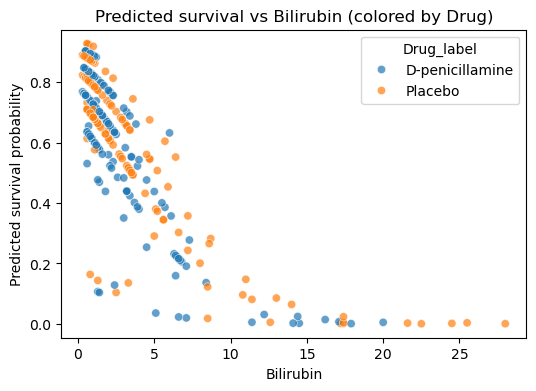

In [559]:
# 3.3
DATA["Drug_label"] = DATA["Drug_Placebo"].map({
    False: "D-penicillamine",
    True: "Placebo",
    0: "D-penicillamine",
    1: "Placebo"
})

DATA["p_survival"] = reg.predict_proba(X)[:, 0]

plt.figure(figsize=(6,4))

sns.scatterplot(
    data=DATA,
    x="Bilirubin",
    y="p_survival",
    hue="Drug_label",
    alpha=0.7
)
plt.xlabel("Bilirubin")
plt.ylabel("Predicted survival probability")
plt.title("Predicted survival vs Bilirubin (colored by Drug)")
plt.show()

Bilirubin level that is lower than 10 increases the predicted survival probability. Surprisingly, patients who did not take the drug have higher the predicted survival probability.

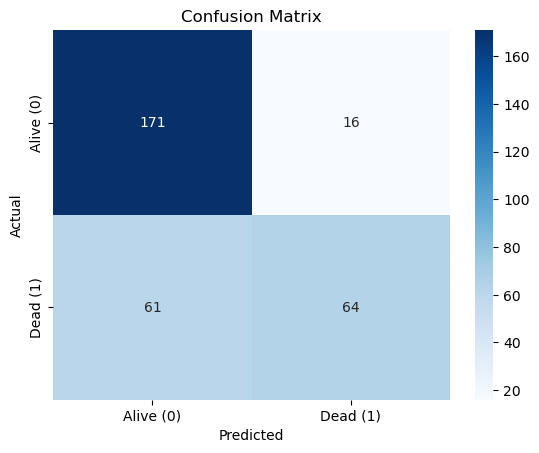

Accuracy: 0.7532051282051282


In [560]:
# 3.4
y_pred = reg.predict(X)

cm = confusion_matrix(y, y_pred)

sns.heatmap(
    cm,
    annot=True,        
    fmt="d",         
    cmap="Blues",
    xticklabels=["Alive (0)", "Dead (1)"],
    yticklabels=["Alive (0)", "Dead (1)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

acc = accuracy_score(y, y_pred)
print("Accuracy:", acc)

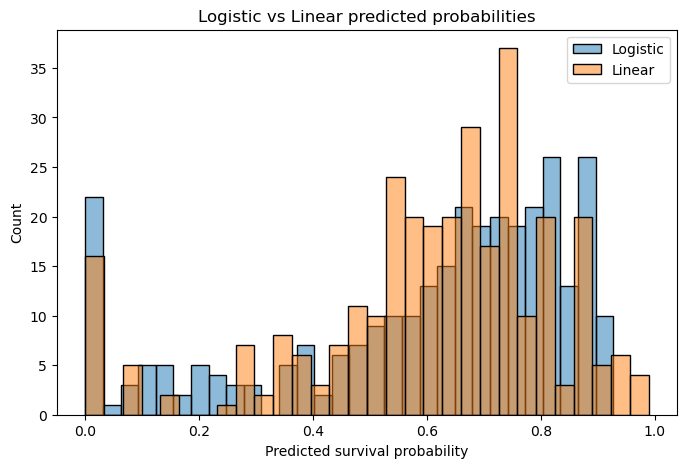

In [561]:
# 3.5
linear = LinearRegression()
linear.fit(X, y)

# predicted "probabilities"
DATA["p_survival_linear"] = 1 - linear.predict(X)   
DATA["p_survival_linear"] = DATA["p_survival_linear"].clip(0, 1)

plt.figure(figsize=(8,5))

sns.histplot(
    DATA["p_survival"],
    bins=30,
    alpha=0.5,
    label="Logistic"
)

sns.histplot(
    DATA["p_survival_linear"],
    bins=30,
    alpha=0.5,
    label="Linear"
)

plt.legend()
plt.xlabel("Predicted survival probability")
plt.title("Logistic vs Linear predicted probabilities")
plt.show()


The performance of linear and logistic regressions are very similar this time.

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


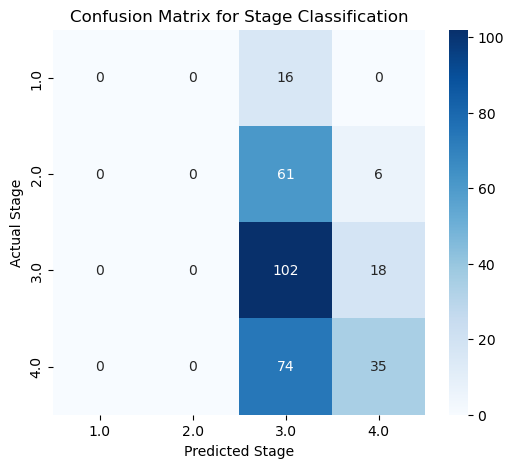

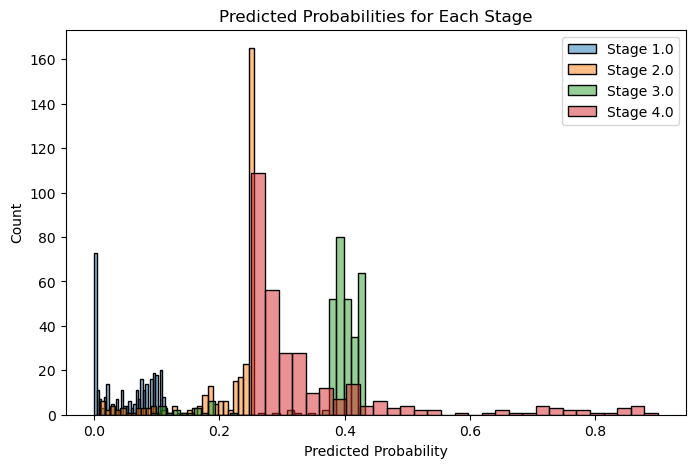

In [562]:
# 3.6

# set stage
X_stage = DATA[["Bilirubin", "Edema_S", "Edema_Y"]]
y_stage = DATA["Stage"]

# fit model
reg.fit(X_stage, y_stage)
y_stage_pred = reg.predict(X_stage)

# confusion matrix
cm_stage = confusion_matrix(y_stage, y_stage_pred)
labels = sorted(y_stage.unique())

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_stage,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Stage")
plt.ylabel("Actual Stage")
plt.title("Confusion Matrix for Stage Classification")

plt.show()

# predicted probabilities
probs_stage = reg.predict_proba(X_stage)

# probability table
probs_stage_df = pd.DataFrame(
    probs_stage,
    columns=reg.classes_
)


# plot predicted probabilities for each class
plt.figure(figsize=(8, 5))
for col in probs_stage_df.columns:
    sns.histplot(probs_stage_df[col], bins=30, alpha=0.5, label=f"Stage {col}")

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Predicted Probabilities for Each Stage")
plt.legend()
plt.show()

The hard classification does not predict every class, as some stages are never selected as the most likely outcome (0s in cm). However, the predicted probabilities from predict_proba assign probabilities to all classes for each observation, which means that every stage is represented in the probability outputs even if not chosen in the final prediction.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

![description](IMG_9312.jpeg)